In [52]:
"""
Symmetric distillation factory search.

For Section II of the paper: enumerate (n, l, d) factories satisfying the
master condition (Theorem 1):

    sum_{w in W, w >= i} C(n-i, w-i)  is a multiple of  2^(l-i+1)
    for all i in {1, ..., l}

where l is the level (theta = pi/2^l) and d is the desired error distance.

The arithmetic-progression case W = {w : w == 1 mod s, w <= n} with s = d-1
gives a closed-form n_min via the roots-of-unity filter. For general W,
we enumerate subsets of {1, ..., n} satisfying the divisibility
constraint directly.
"""

from math import comb
from itertools import combinations


# --- Closed-form arithmetic-progression case ----------------------------------

def check_arith_prog(n, l, s):
    """
    Check if W = {w : w == 1 mod s, w <= n} satisfies the master condition.

    For s = 1, 2 the roots-of-unity filter gives a clean condition.
    For s >= 3, we test the divisibility directly.
    """
    W = [w for w in range(1, n + 1) if (w - 1) % s == 0]
    if not W:
        return False
    return check_W(n, l, W)


def check_W(n, l, W):
    """
    Check if a gate set W satisfies the master condition at level l.

    Eq.: sum_{w in W, w >= i} C(n-i, w-i) ≡ 0 mod 2^(l-i+1)
    for all i in {1, ..., l}.
    """
    for i in range(1, l + 1):
        s = sum(comb(n - i, w - i) for w in W if w >= i)
        modulus = 1 << (l - i + 1)  # 2^(l-i+1)
        if s % modulus != 0:
            return False
    return True


def find_n_min_arith(l, d):
    """
    Find the smallest n for which W = {w == 1 mod (d-1), w <= n} works.

    Returns None if no solution exists for n in [d, ..., 2*l + 5].
    """
    s = d - 1
    if s < 1:
        return None
    for n in range(d, 2 * l + 6):
        if check_arith_prog(n, l, s):
            return n
    return None


def closed_form_table(l_range, d_range):
    """Print the n_min table for arithmetic-progression gate sets."""
    print("Closed-form n_min for W = {w == 1 mod (d-1)}:")
    print(f"  {'l':<4}", end="")
    for d in d_range:
        print(f"{f'd={d}':<10}", end="")
    print()
    for l in l_range:
        print(f"  {l:<4}", end="")
        for d in d_range:
            n = find_n_min_arith(l, d)
            print(f"{str(n) if n else '---':<10}", end="")
        print()


# --- General gate-set search --------------------------------------------------

def find_factories_general(l, d, n_max=10):
    """
    Search ALL gate sets W subset of {1, ..., n} satisfying the master
    condition with minimum gate weight >= 1 and weight separation >= d-1.

    Returns list of (n, W) tuples.
    """
    results = []
    s = d - 1  # minimum weight separation enforces distance d
    for n in range(d, n_max + 1):
        # Enumerate non-empty W with weights satisfying separation s
        for size in range(1, n + 1):
            for W in combinations(range(1, n + 1), size):
                # Enforce weight separation s
                if any(W[i+1] - W[i] < s for i in range(len(W) - 1)):
                    continue
                # Must contain weight 1 to make output qubits removable
                if 1 not in W:
                    continue
                if check_W(n, l, list(W)):
                    results.append((n, list(W)))
                    break  # take smallest W for each n
            else:
                continue
            break
    return results


def general_search_table(l_range, d_range, n_max=10):
    """Print a table of n_min via full search."""
    print(f"General search n_min (n <= {n_max}, weight-separated W with 1 in W):")
    print(f"  {'l':<4}", end="")
    for d in d_range:
        print(f"{f'd={d}':<10}", end="")
    print()
    for l in l_range:
        print(f"  {l:<4}", end="")
        for d in d_range:
            results = find_factories_general(l, d, n_max=n_max)
            if results:
                print(f"{results[0][0]:<10}", end="")
            else:
                print(f"{'---':<10}", end="")
        print()


# --- Main ---------------------------------------------------------------------

if __name__ == "__main__":
    L_RANGE = [2, 3, 4]
    D_RANGE = [2, 3, 4, 5]

    closed_form_table(L_RANGE, D_RANGE)
    print()
    general_search_table(L_RANGE, D_RANGE, n_max=10)

Closed-form n_min for W = {w == 1 mod (d-1)}:
  l   d=2       d=3       d=4       d=5       
  2   3         4         ---       7         
  3   4         5         ---       9         
  4   5         6         ---       11        

General search n_min (n <= 10, weight-separated W with 1 in W):
  l   d=2       d=3       d=4       d=5       
  2   3         4         7         7         
  3   4         5         9         9         
  4   5         6         ---       ---       


/var/folders/k1/xhhmv5bx629_dx3jv43kpn_80000gr/T/ipykernel_90704/495622291.py:213: UserWarning: Adding colorbar to a different Figure <Figure size 1100x650 with 2 Axes> than <Figure size 1000x650 with 2 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(sc, ax=ax, boundaries=bounds, ticks=all_ls, spacing="proportional", pad=0.02)


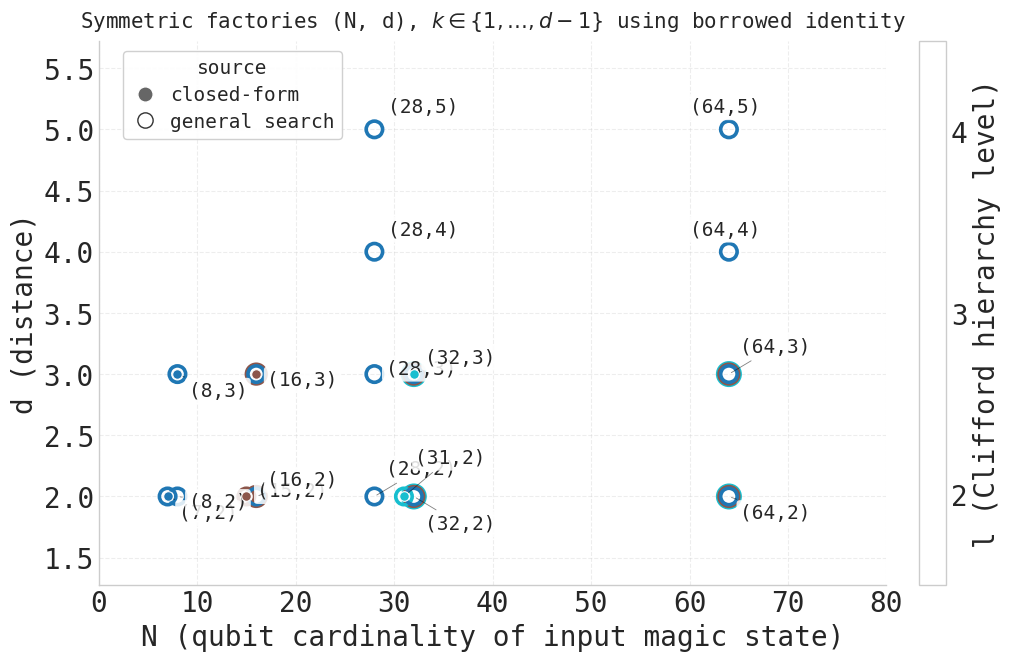

In [54]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "DejaVu Sans Mono",
    "font.size": 18,
})


# User-defined Section-II parameters:
#   N = sum_{w in W} C(n, w)
#   k is any integer in {1, ..., d-1}; we do not enumerate k on the plot.
def _factory_N(n, W):
    return sum(comb(n, w) for w in W)


def _collect_closed_form_points(l_range, d_range):
    points = []
    for l in l_range:
        for d in d_range:
            if d > 3:
                continue
            n = find_n_min_arith(l, d)
            if n is None:
                continue
            s = d - 1
            W = [w for w in range(1, n + 1) if (w - 1) % s == 0]
            N = _factory_N(n, W)
            points.append({"n": n, "N": N, "d": d, "l": l, "source": "closed"})
    return points


def _collect_general_points(l_range, d_range, n_max=10):
    points = []
    for l in l_range:
        for d in d_range:
            results = find_factories_general(l, d, n_max=n_max)
            for n, W in results:
                N = _factory_N(n, W)
                points.append({"n": n, "N": N, "d": d, "l": l, "source": "general"})
    return points


def _discrete_l_palette(ls):
    base = plt.get_cmap("tab10", len(ls))
    colors = [base(i) for i in range(len(ls))]
    cmap = ListedColormap(colors)
    if len(ls) == 1:
        bounds = [ls[0] - 0.5, ls[0] + 0.5]
    else:
        bounds = [ls[0] - 0.5] + [val + 0.5 for val in ls]
    norm = BoundaryNorm(bounds, cmap.N)
    return cmap, norm, bounds


def _spread_overlaps(points):
    grouped = {}
    for p in points:
        key = (p["N"], p["d"])
        grouped.setdefault(key, []).append(p)

    spread = []
    x_offsets = [0.0, -1.0, 1.0, -2.0, 2.0, -3.0, 3.0]
    y_offsets = [0.0, 0.03, -0.03, 0.06, -0.06, 0.09, -0.09]

    for (N_val, d_val), entries in grouped.items():
        entries = sorted(entries, key=lambda item: (item["l"], item["source"], item["n"]))
        for idx, p in enumerate(entries):
            q = dict(p)
            q["N_plot"] = N_val + x_offsets[idx % len(x_offsets)]
            q["d_plot"] = d_val + y_offsets[idx % len(y_offsets)]
            spread.append(q)

    return spread


def _plot_single_panel(ax, points, title, cmap, norm, all_ls):
    if not points:
        ax.set_title(title, fontsize=15)
        ax.text(0.5, 0.5, "No factories found", ha="center", va="center", transform=ax.transAxes)
        return None

    # Concentric-circle sizing for coincident (N,d) points across different l.
    ls_by_point = {}
    for p in points:
        key = (p["N"], p["d"])
        ls_by_point.setdefault(key, set()).add(p["l"])

    ring_size = {}
    base_size = 140
    size_step = 60
    for (N_val, d_val), ls_set in ls_by_point.items():
        for rank, l_val in enumerate(sorted(ls_set)):
            ring_size[(N_val, d_val, l_val)] = base_size + size_step * rank

    # Build quick lookup sets
    closed_set = {(p["N"], p["d"], p["l"]) for p in points if p["source"] == "closed"}
    general_set = {(p["N"], p["d"], p["l"]) for p in points if p["source"] == "general"}

    # Prepare ring entries and sort by size descending so larger rings are drawn first
    ring_entries = []
    for (N_val, d_val), ls_set in ls_by_point.items():
        ls_sorted = sorted(ls_set)
        for rank, l_val in enumerate(ls_sorted):
            size = base_size + size_step * rank
            color = cmap(norm(l_val))
            ring_entries.append((size, N_val, d_val, l_val, color))

    ring_entries.sort(reverse=True, key=lambda x: x[0])

    for size, N_val, d_val, l_val, color in ring_entries:
        # Draw an open ring for every (N,d,l)
        ax.scatter(
            [N_val], [d_val],
            facecolors="none",
            edgecolors=[color],
            linewidths=2.6,
            marker="o",
            s=size,
            alpha=1.0,
            zorder=3,
        )
        # If closed-form exists for this triple, draw a small filled dot at center
        if (N_val, d_val, l_val) in closed_set:
            ax.scatter([N_val], [d_val], c=[color], s=48, edgecolors="white", linewidths=0.8, zorder=4)
        # If only general exists and not closed, optionally draw a smaller filled dot for visibility
        elif (N_val, d_val, l_val) in general_set:
            # leave as open ring, no center fill
            pass

    # Label unique (N,d) once for readability.
    label_points = sorted({(p["N"], p["d"]) for p in points}, key=lambda t: (t[1], t[0]))
    
    # Group by d value to handle dense d=2 and d=3 rows
    points_by_d = {}
    for N_val, d_val in label_points:
        if d_val not in points_by_d:
            points_by_d[d_val] = []
        points_by_d[d_val].append((N_val, d_val))
    
    for d_val in sorted(points_by_d.keys()):
        d_points = points_by_d[d_val]
        
        if d_val in [2, 3]:
            # Dense rows: spread vertically using different y offsets
            y_offsets = [-16, -8, 0, 8, 16, 24, -24]
            for idx, (N_val, d_val_check) in enumerate(d_points):
                dy = y_offsets[idx % len(y_offsets)]
                dx = 8
                ax.annotate(
                    f"({N_val},{d_val})",
                    (N_val, d_val_check),
                    textcoords="offset points",
                    xytext=(dx, dy),
                    fontsize=14,
                    bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.85),
                    arrowprops=dict(arrowstyle="-", lw=0.6, alpha=0.5) if dy != 0 else None,
                )
        else:
            # Sparse rows: use simple alternating pattern
            for idx, (N_val, d_val_check) in enumerate(d_points):
                dx = 10 if idx % 2 == 0 else -28
                dy = 12 if idx % 2 == 0 else 12
                ax.annotate(
                    f"({N_val},{d_val})",
                    (N_val, d_val_check),
                    textcoords="offset points",
                    xytext=(dx, dy),
                    fontsize=14,
                    bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.85),
                )

    ax.set_title(title, fontsize=15, pad=10)
    ax.set_xlabel("N (qubit cardinality of input magic state)", fontsize=20)
    ax.set_ylabel("d (distance)", fontsize=20)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.tick_params(axis="both", labelsize=20)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, 80)
    ax.margins(x=0.0, y=0.24)
    return sc


# Defaults if not already defined in the first cell
L_VALUES = L_RANGE if "L_RANGE" in globals() else [2, 3, 4]
D_VALUES = D_RANGE if "D_RANGE" in globals() else [2, 3, 4, 5]
N_MAX_GENERAL = 10

closed_points = _collect_closed_form_points(L_VALUES, D_VALUES)
general_points = _collect_general_points(L_VALUES, D_VALUES, n_max=N_MAX_GENERAL)
all_points = closed_points + general_points

all_ls = sorted({p["l"] for p in all_points})

cmap, norm, bounds = _discrete_l_palette(all_ls)

fig, ax = plt.subplots(figsize=(10, 6.5), constrained_layout=True)
sc = _plot_single_panel(
    ax,
    all_points,
    r"Symmetric factories (N, d), $k \in \{1,\ldots,d-1\}$ using borrowed identity",
    cmap,
    norm,
    all_ls,
)

# Shared discrete colorbar for l
if sc is not None:
    cbar = fig.colorbar(sc, ax=ax, boundaries=bounds, ticks=all_ls, spacing="proportional", pad=0.02)
    cbar.set_label("l (Clifford hierarchy level)", fontsize=20)
    cbar.ax.tick_params(labelsize=20)

# Compact source legend inside the axes, where there is empty space.
source_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#666", markeredgecolor="white", markersize=11, label="closed-form"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="none", markeredgecolor="#333", markersize=11, label="general search"),
]
ax.legend(
    handles=source_handles,
    title="source",
    loc="upper left",
    bbox_to_anchor=(1.5, 5.72),
    bbox_transform=ax.transData,
    frameon=True,
    fancybox=True,
    framealpha=0.92,
    fontsize=14,
    title_fontsize=14,
    borderpad=0.4,
    labelspacing=0.4,
    handletextpad=0.6,
    handlelength=1.4,
)

plt.show()

In [ ]:
fix this above plot. fix the plot below. fix the caption for figure 1. Do the same for figure 2 next

In [2]:
"""
Symmetric distillation factory search and plotting.

FIX: Use scatter markers (sized in display points, not data units) so
circles render as true circles regardless of axis aspect/scale.
For each (N, d) coordinate, we draw concentric circles — one per l —
with size growing in l. They share a center and are all visible because
larger-l circles are drawn first (back) and smaller-l circles on top.
"""

from math import comb
from itertools import combinations

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D


# --- Core verifier ------------------------------------------------------------

def check_W(n, l, W):
    for i in range(1, l + 1):
        s = sum(comb(n - i, w - i) for w in W if w >= i)
        modulus = 1 << (l - i + 1)
        if s % modulus != 0:
            return False
    return True


# --- Three solution methods ---------------------------------------------------

def closed_form_n_min(l, d):
    if d == 2:
        return l + 1
    if d == 3:
        return l + 2
    return None


def find_n_min_arith(l, d, n_max=12):
    s = d - 1
    if s < 1:
        return None
    for n in range(d, n_max + 1):
        W = [w for w in range(1, n + 1) if (w - 1) % s == 0]
        if W and check_W(n, l, W):
            return n
    return None


def find_n_min_general(l, d, n_max=12):
    s = d - 1
    for n in range(d, n_max + 1):
        for size in range(1, n + 1):
            for W in combinations(range(1, n + 1), size):
                if any(W[i + 1] - W[i] < s for i in range(len(W) - 1)):
                    continue
                if 1 not in W:
                    continue
                if check_W(n, l, list(W)):
                    return n, list(W)
    return None, None


def fmt(x):
    return str(x) if x is not None else "---"


def three_method_table(l_range, d_range, n_max=12):
    print(f"{'l':<4}{'d':<4}{'Closed-form':<14}"
          f"{'Arith-prog':<14}{'General':<14}")
    print("-" * 50)
    for l in l_range:
        for d in d_range:
            cf = closed_form_n_min(l, d)
            ap = find_n_min_arith(l, d, n_max=n_max)
            gen, _ = find_n_min_general(l, d, n_max=n_max)
            print(f"{l:<4}{d:<4}{fmt(cf):<14}{fmt(ap):<14}{fmt(gen):<14}")


# --- Plotting setup -----------------------------------------------------------

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,
})


def _factory_N(n, W):
    return sum(comb(n, w) for w in W)


def _resolve_method(l, d, n_max):
    n_cf = closed_form_n_min(l, d)
    if n_cf is not None:
        s = d - 1
        W = [w for w in range(1, n_cf + 1) if (w - 1) % s == 0]
        return ("closed", n_cf, W)
    n_ap = find_n_min_arith(l, d, n_max=n_max)
    if n_ap is not None:
        s = d - 1
        W = [w for w in range(1, n_ap + 1) if (w - 1) % s == 0]
        return ("arith", n_ap, W)
    n_gen, W_gen = find_n_min_general(l, d, n_max=n_max)
    if n_gen is not None:
        return ("general", n_gen, W_gen)
    return (None, None, None)


def _collect_points(l_range, d_range, n_max=12):
    """
    Build the point list with hierarchy inclusion:
      The master condition is monotone in l. If a factory (n, W) satisfies
      the condition at level l_max, it satisfies it at every l <= l_max.
      So whenever we resolve a factory at l_max for a given d, we also
      register it as a valid factory at every smaller l in l_range.

    To avoid duplicates at a fixed (N, d, l), we keep at most one entry
    per (N, d, l) and prefer the highest-priority resolution method
    (closed > arith > general) among the candidates.
    """
    method_rank = {"closed": 3, "arith": 2, "general": 1}
    by_key = {}  # (N, d, l) -> entry

    for l_solved in l_range:
        for d in d_range:
            method, n, W = _resolve_method(l_solved, d, n_max)
            if method is None:
                continue
            N = _factory_N(n, W)
            # Register this factory at l_solved AND every smaller l in l_range.
            for l in l_range:
                if l > l_solved:
                    continue
                key = (N, d, l)
                entry = {
                    "n": n, "N": N, "d": d, "l": l,
                    "method": method, "l_solved": l_solved,
                }
                # Keep the higher-priority method if a duplicate exists.
                prev = by_key.get(key)
                if prev is None or method_rank[method] > method_rank[prev["method"]]:
                    by_key[key] = entry

    return list(by_key.values())


def _discrete_l_palette(ls):
    base = plt.get_cmap("viridis", len(ls))
    colors = [base(i) for i in range(len(ls))]
    cmap = ListedColormap(colors)
    if len(ls) == 1:
        bounds = [ls[0] - 0.5, ls[0] + 0.5]
    else:
        bounds = [ls[0] - 0.5] + [val + 0.5 for val in ls]
    norm = BoundaryNorm(bounds, cmap.N)
    return cmap, norm, bounds


# --- Main plot function -------------------------------------------------------

def plot_symmetric_factories(points, all_ls, cmap, norm, ax,
                              anchor_l=3,
                              base_size=900, size_step=900):
    """
    Plot factories as concentric circular markers (in display units, so they
    are true circles regardless of axis aspect).

    For each (N, d), draw one marker per l value, sharing the same center.
      - Color encodes l (viridis).
      - Marker AREA encodes l: larger l => larger circle.
      - Marker fill at the *innermost-l* (smallest-l) marker is determined
        by the method at anchor_l (default l=3):
            closed  -> solid color fill
            arith   -> hatched-style (we use a striped marker proxy: white
                       core with thicker colored edge) since scatter
                       doesn't directly support hatching per marker. We
                       approximate with a "ring" look (open + thick edge).
            general -> open ring with thicker edge
        For non-innermost l, we draw open rings (just the colored edge)
        so all rings remain visible at the same center.

    Args:
        base_size: marker area (in points^2) for the smallest l.
        size_step: increment in marker area per l step.
    """
    if not points:
        ax.text(0.5, 0.5, "No factories found",
                ha="center", va="center", transform=ax.transAxes)
        return None

    sorted_ls = sorted(all_ls)
    sizes = {l_val: base_size + size_step * idx
             for idx, l_val in enumerate(sorted_ls)}

    # Group points by (N, d) coordinate.
    grouped = {}
    for p in points:
        grouped.setdefault((p["N"], p["d"]), []).append(p)

    # Encoding:
    #   - Each l value gets a colored ring (color from cmap, size from l).
    #   - The INNERMOST ring (smallest l present) carries a GRAY fill
    #     style that encodes the solver method of the LARGEST-l factory
    #     at this (N, d) — i.e. the highest Clifford-hierarchy level for
    #     which this (N, d) supports a factory:
    #         closed  -> filled gray disk
    #         arith   -> gray × overlay
    #         general -> plain open ring
    #   - All non-innermost rings are plain colored outlines.
    fill_gray = "#666"
    for (N_val, d_val), entries in grouped.items():
        ls_present = sorted({p["l"] for p in entries})
        innermost_l = ls_present[0]
        largest_l = ls_present[-1]

        # Method of the LARGEST-l factory at this (N, d). For inherited
        # entries (added via downward monotonicity), we want the method
        # of the original solver call at the highest l this (N, d)
        # achieves — i.e. the entry whose l == largest_l.
        largest_method = None
        for p in entries:
            if p["l"] == largest_l:
                largest_method = p["method"]
                break

        for l_val in sorted(ls_present, reverse=True):
            color = cmap(norm(l_val))
            size = sizes[l_val]
            is_innermost = (l_val == innermost_l)

            # Colored ring outline for every l.
            ax.scatter([N_val], [d_val], s=size,
                       facecolor="none", edgecolor=color,
                       linewidth=1.3, zorder=10 - l_val)

            # Gray fill style overlaid on the innermost ring, driven by
            # how the LARGEST-l factory was solved.
            if is_innermost:
                if largest_method == "closed":
                    ax.scatter([N_val], [d_val], s=size * 0.92,
                               facecolor=fill_gray, edgecolor="none",
                               alpha=0.85, zorder=10 - l_val - 0.1)
                elif largest_method == "arith":
                    ax.scatter([N_val], [d_val], s=size * 0.55,
                               marker="x", color=fill_gray,
                               linewidth=1.3, zorder=10 - l_val + 0.1)
                # general: leave as plain open ring.

    # Mappable for the colorbar. Using ScalarMappable directly is more
    # reliable than a hidden scatter (s=0, alpha=0 can leave the colorbar
    # blank on some backends).
    sc_for_colorbar = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sc_for_colorbar.set_array([p["l"] for p in points])

    # Annotate each unique (N, d) once, off to the side so the rings
    # are not occluded.
    label_coords = sorted({(p["N"], p["d"]) for p in points},
                          key=lambda t: (t[1], t[0]))
    for N_val, d_val in label_coords:
        ax.annotate(
            f"({N_val},{d_val})",
            (N_val, d_val),
            textcoords="offset points",
            xytext=(0, -22),
            fontsize=6.5, ha="center",
            bbox=dict(boxstyle="round,pad=0.15",
                      fc="white", ec="gray", alpha=0.9, lw=0.4),
            arrowprops=dict(arrowstyle="-", lw=0.5, alpha=0.4),
            zorder=10,
        )

    ax.set_xlabel("$N$ (qubit cardinality of input magic state)", fontsize=8)
    ax.set_ylabel("$d$ (distance)", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.35, linewidth=0.4)
    ax.tick_params(axis="both", labelsize=7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)

    return sc_for_colorbar


# --- Auto-segmenting helpers --------------------------------------------------

def _find_segments(Ns, pad_frac=0.15, gap_factor=2.5):
    """
    Cluster a sorted list of N values into segments. A new segment starts
    whenever the gap between consecutive values is large compared to the
    smaller of the two values straddling the gap (this catches both
    log-spread and linear-spread layouts).

    Each segment is returned as (lo, hi) with a small padding so markers
    aren't clipped at the edges.
    """
    if not Ns:
        return []
    Ns = sorted(set(Ns))
    if len(Ns) == 1:
        n = Ns[0]
        pad = max(2, abs(n) * pad_frac)
        return [(n - pad, n + pad)]

    clusters = [[Ns[0]]]
    for i in range(1, len(Ns)):
        prev = Ns[i - 1]
        curr = Ns[i]
        gap = curr - prev
        # New segment if the gap is more than gap_factor times the smaller
        # of {prev, gap to nearest cluster member}. This makes segmentation
        # scale-aware: large gaps at large N are tolerated more, but big
        # relative jumps at any scale split.
        ref = max(prev, 4)
        if gap > gap_factor * ref:
            clusters.append([curr])
        else:
            clusters[-1].append(curr)

    segments = []
    for cl in clusters:
        lo, hi = cl[0], cl[-1]
        span = max(hi - lo, 1)
        pad = max(2.0, span * pad_frac, lo * 0.04)
        segments.append((max(0, lo - pad), hi + pad))
    return segments


def _draw_axis_breaks(axes, d_marker_size=0.012):
    """
    Draw small diagonal marks between adjacent broken-axis subplots
    to indicate the discontinuity. axes is a list of side-by-side Axes
    sharing the y-axis.
    """
    if len(axes) < 2:
        return
    for i, ax in enumerate(axes):
        # Hide spines facing the break.
        if i > 0:
            ax.spines["left"].set_visible(False)
            ax.tick_params(axis="y", which="both", left=False, labelleft=False)
        if i < len(axes) - 1:
            ax.spines["right"].set_visible(False)

    # Place diagonal break ticks on each shared edge using axes coords.
    kwargs = dict(color="k", clip_on=False, lw=1.2)
    for i in range(len(axes) - 1):
        left_ax = axes[i]
        right_ax = axes[i + 1]
        d = d_marker_size
        # Right edge of left_ax
        left_ax.plot([1 - d, 1 + d], [-d, d],
                     transform=left_ax.transAxes, **kwargs)
        left_ax.plot([1 - d, 1 + d], [1 - d, 1 + d],
                     transform=left_ax.transAxes, **kwargs)
        # Left edge of right_ax
        right_ax.plot([-d, d], [-d, d],
                     transform=right_ax.transAxes, **kwargs)
        right_ax.plot([-d, d], [1 - d, 1 + d],
                     transform=right_ax.transAxes, **kwargs)


# --- Main ---------------------------------------------------------------------

if __name__ == "__main__":
    L_RANGE = [2, 3, 4]
    D_RANGE = [2, 3, 4, 5]
    N_MAX = 8
    N_CUTOFF = 10**9  # effectively no cutoff; segments handle the spread

    print("=" * 60)
    print("Symmetric distillation factory search")
    print(f"l in {L_RANGE}, d in {D_RANGE}, n_max = {N_MAX}")
    print("=" * 60)
    print("\nn_min by solution method:\n")
    three_method_table(L_RANGE, D_RANGE, n_max=N_MAX)
    print()

    all_points = _collect_points(L_RANGE, D_RANGE, n_max=N_MAX)
    all_points = [p for p in all_points if p["N"] <= N_CUTOFF]

    print(f"Points after filter (N <= {N_CUTOFF}): {len(all_points)}")
    if not all_points:
        print("No points to plot.")
    else:
        all_ls = sorted({p["l"] for p in all_points})
        cmap, norm, bounds = _discrete_l_palette(all_ls)

        # Detect segments along N. A smaller gap_factor makes the
        # segmenter more eager to split; tune to taste.
        all_Ns = sorted({p["N"] for p in all_points})
        segments = _find_segments(all_Ns, pad_frac=0.20, gap_factor=0.5)
        print(f"Detected N segments: {[(round(lo), round(hi)) for lo, hi in segments]}")

        # Width-weight each subplot by its log-scaled N span so very wide
        # ranges don't crush the narrow ones.
        from math import sqrt, log10
        widths = [max(1.0, log10(max(hi - lo, 2)) + 0.5) for lo, hi in segments]

        # Single-column figure size for a two-column paper (~3.4" wide).
        fig, axes = plt.subplots(
            1, len(segments),
            figsize=(3.4, 2.6),
            sharey=True,
            gridspec_kw={"width_ratios": widths, "wspace": 0.10},
            constrained_layout=True,
        )
        if len(segments) == 1:
            axes = [axes]

        sc = None
        for ax_i, (ax, (lo, hi)) in enumerate(zip(axes, segments)):
            seg_pts = [p for p in all_points if lo <= p["N"] <= hi]
            sc_i = plot_symmetric_factories(
                seg_pts, all_ls, cmap, norm, ax,
                anchor_l=3, base_size=140, size_step=180,
            )
            ax.set_xlim(lo, hi)
            ax.set_ylim(1, max(D_RANGE) + 1)
            ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=2, integer=True))
            if ax_i != 0:
                ax.set_ylabel("")
            if ax_i != len(segments) // 2:
                ax.set_xlabel("")
            if sc is None and sc_i is not None:
                sc = sc_i

        _draw_axis_breaks(axes, d_marker_size=0.018)

        # Discrete colorbar for ℓ (attached to the rightmost axis).
        if sc is not None:
            cbar = fig.colorbar(
                sc, ax=axes, boundaries=bounds, ticks=all_ls,
                spacing="proportional", pad=0.03,
            )
            cbar.set_label(r"$\ell$ (Clifford hierarchy level)", fontsize=8)
            cbar.ax.tick_params(labelsize=7, width=0.5, length=2)
            cbar.outline.set_linewidth(0.5)

        # Legend on the rightmost axis.
        from matplotlib.legend_handler import HandlerTuple
        ring_color = "#444"
        fill_gray = "#666"
        # Closed-form: outline ring + filled gray dot CENTERED inside.
        h_closed_ring = Line2D([0], [0], marker="o", color="w",
                               markerfacecolor="none",
                               markeredgecolor=ring_color,
                               markersize=7, markeredgewidth=1.2)
        h_closed_fill = Line2D([0], [0], marker="o", color="w",
                               markerfacecolor=fill_gray,
                               markeredgecolor="none",
                               markersize=4.2, alpha=0.85)
        # AP: outline ring + gray × CENTERED inside.
        h_ap_ring = Line2D([0], [0], marker="o", color="w",
                           markerfacecolor="none",
                           markeredgecolor=ring_color,
                           markersize=7, markeredgewidth=1.2)
        h_ap_cross = Line2D([0], [0], marker="x", color=fill_gray,
                            markersize=3.8, markeredgewidth=1.2,
                            linestyle="None")
        # General: just the ring.
        h_general = Line2D([0], [0], marker="o", color="w",
                           markerfacecolor="none",
                           markeredgecolor=ring_color,
                           markersize=7, markeredgewidth=1.2)
        fig.legend(
            handles=[(h_closed_ring, h_closed_fill),
                     (h_ap_ring, h_ap_cross),
                     h_general],
            labels=["closed-form", "AP search", "general"],
            # ndivide=1 places both glyphs in the SAME slot (overlapping)
            # instead of side-by-side. This is what makes the dot/cross
            # appear centered inside the ring.
            handler_map={tuple: HandlerTuple(ndivide=1, pad=0)},
            title=r"largest-$\ell$ method:",
            loc="upper center",
            bbox_to_anchor=(0.5, 1.10),
            ncol=3,
            frameon=False,
            fontsize=6.5, title_fontsize=6.5,
            handletextpad=0.4, borderpad=0.3, columnspacing=0.9,
        )


        plt.savefig("code_II.png", dpi=110, bbox_inches="tight")
        print("saved code_II.png")

Symmetric distillation factory search
l in [2, 3, 4], d in [2, 3, 4, 5], n_max = 8

n_min by solution method:

l   d   Closed-form   Arith-prog    General       
--------------------------------------------------
2   2   3             3             3             
2   3   4             4             4             
2   4   ---           ---           7             
2   5   ---           7             7             
3   2   4             4             4             
3   3   5             5             5             
3   4   ---           ---           ---           
3   5   ---           ---           ---           
4   2   5             5             5             
4   3   6             6             6             
4   4   ---           ---           ---           
4   5   ---           ---           ---           

Points after filter (N <= 1000000000): 14
Detected N segments: [(5, 10), (13, 18), (26, 34)]
saved code_II.png


In [41]:
pdf_path = "/Users/shraddhasingh/Documents/GitHub/Magic_Factory_Search/code_II.pdf"
fig.savefig(pdf_path, bbox_inches="tight")
print(pdf_path)

/Users/shraddhasingh/Documents/GitHub/Magic_Factory_Search/code_II.pdf
